# Beat the Streak — First ML Model

**Goal:** Predict `got_hit` (binary) from features stored in the `Prediction` table.

Steps:
1. Load data from Django DB
2. Parse `score_breakdown` for raw features
3. Build feature matrix
4. Time-based train/test split
5. Logistic regression baseline
6. Random forest
7. Compare vs. existing hand-crafted `score`

In [1]:
import sys, os                                                                                                                                                         
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))                                                                                                      
sys.path.insert(0, PROJECT_ROOT)                                                                                                                                       
os.environ['DJANGO_SETTINGS_MODULE'] = 'config.settings.dev'
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = 'true'                                                                                                                       
os.environ['DATABASE_URL'] = f'sqlite:///{PROJECT_ROOT}/db.sqlite3'                                                                                                    
import django                                                                                                                                                          
django.setup()                                                                                                                                                         
print('Django ready')  

Django ready


In [2]:
import re
import numpy as np
import pandas as pd
from predictor.models import Prediction

# Load all rows that have a resolved outcome
qs = Prediction.objects.exclude(got_hit=None).values(
    'date', 'name', 'bats', 'list_type',
    'score',
    'pitcher_hand', 'pitcher_era', 'pitcher_whip',
    'is_home', 'avg_batting_order', 'park_factor',
    'team_rank', 'hit_streak',
    'score_breakdown',
    'got_hit',
)

df = pd.DataFrame.from_records(qs)
print(f'Loaded {len(df)} rows across {df["date"].nunique()} dates')
print(f'Hit rate: {df["got_hit"].mean():.1%}')
df.head(3)

Loaded 2093 rows across 178 dates
Hit rate: 64.5%


,date,name,bats,list_type,score,pitcher_hand,pitcher_era,pitcher_whip,is_home,avg_batting_order,park_factor,team_rank,hit_streak,score_breakdown,got_hit
0,2026-03-29,Shea Langeliers,R,A,98.8,L,NaN,NaN,False,2.0,100,15.0,2,P(Hit): 98.8% | BA: 0.600 | xBA: 0.719 | HH%: ...,True
1,2026-03-30,Yandy Díaz,R,A,98.5,L,NaN,NaN,False,1.0,103,5.0,3,P(Hit): 98.5% | BA: 0.562 | xBA: 0.424 | HH%: ...,True
2,2026-03-31,Yandy Díaz,R,B,98.1,R,NaN,NaN,False,1.0,103,7.0,4,P(Hit): 98.1% | BA: 0.550 | xBA: 0.449 | HH%: ...,False


## Parse `score_breakdown` for raw features

The breakdown string looks like:
```
P(Hit): 74.2% | BA: 0.285 | xBA: 0.310 | HH%: 42% | K%: 15.2% (+0.5σ) | BB%: 8.1% | Speed: 28.3 ft/s | ...
```

In [3]:
def parse_breakdown(s):
    """Extract numeric features from score_breakdown string."""
    result = {}
    if not s:
        return result

    patterns = {
        'ba':       r'BA:\s*([0-9.]+)',
        'xba':      r'xBA:\s*([0-9.]+)',
        'hh_pct':   r'HH%:\s*([0-9.]+)',
        'k_pct':    r'K%:\s*([0-9.]+)',
        'bb_pct':   r'BB%:\s*([0-9.]+)',
        'speed':    r'Speed:\s*([0-9.]+)',
        'p_era':    r'P\.ERA:\s*([0-9.]+)',
        'p_whip':   r'P\.WHIP:\s*([0-9.]+)',
        'p_k9':     r'P\.K/9:\s*([0-9.]+)',
    }

    for key, pat in patterns.items():
        m = re.search(pat, s)
        result[key] = float(m.group(1)) if m else np.nan

    return result

parsed = df['score_breakdown'].apply(parse_breakdown)
parsed_df = pd.DataFrame(parsed.tolist(), index=df.index)

print('Parsed features coverage (non-null %)')
print((parsed_df.notna().mean() * 100).round(1).to_string())

Parsed features coverage (non-null %)
ba        100.0
xba        96.0
hh_pct     96.0
k_pct     100.0
bb_pct     95.9
speed      95.7
p_era      84.1
p_whip      0.0
p_k9        0.0


## Build feature matrix

In [4]:
df = pd.concat([df.reset_index(drop=True), parsed_df.reset_index(drop=True)], axis=1)

# Encode categoricals
df['bats_L']    = (df['bats'] == 'L').astype(int)
df['bats_S']    = (df['bats'] == 'S').astype(int)   # switch
df['pitch_R']   = (df['pitcher_hand'] == 'R').astype(int)
df['pitch_L']   = (df['pitcher_hand'] == 'L').astype(int)
df['platoon']   = ((df['bats'] == 'L') & (df['pitcher_hand'] == 'R') |
                   (df['bats'] == 'R') & (df['pitcher_hand'] == 'L')).astype(int)
df['is_a_list'] = (df['list_type'] == 'A').astype(int)

FEATURE_COLS = [
    'score',
    'ba', 'xba', 'hh_pct', 'k_pct', 'bb_pct', 'speed',
    'is_home', 'park_factor', 'avg_batting_order', 'hit_streak',
    'pitcher_era', 'pitcher_whip', 'p_era',
    'team_rank',
    'bats_L', 'bats_S', 'pitch_R', 'pitch_L', 'platoon', 'is_a_list',
]

# Drop any columns that are entirely null
FEATURE_COLS = [c for c in FEATURE_COLS if df[c].notna().any()]

X = df[FEATURE_COLS].copy()
y = df['got_hit'].astype(int)

print(f'Feature matrix: {X.shape}')
print(f'Features used: {FEATURE_COLS}')
print(f'Class balance: {y.mean():.1%} hits')
X.describe().round(3)

Feature matrix: (2093, 21)
Features used: ['score', 'ba', 'xba', 'hh_pct', 'k_pct', 'bb_pct', 'speed', 'is_home', 'park_factor', 'avg_batting_order', 'hit_streak', 'pitcher_era', 'pitcher_whip', 'p_era', 'team_rank', 'bats_L', 'bats_S', 'pitch_R', 'pitch_L', 'platoon', 'is_a_list']
Class balance: 64.5% hits


,score,ba,xba,hh_pct,k_pct,bb_pct,speed,park_factor,avg_batting_order,hit_streak,pitcher_era,pitcher_whip,p_era,team_rank,bats_L,bats_S,pitch_R,pitch_L,platoon,is_a_list
count,2093.000,2093.000,2010.000,2010.000,2093.000,2008.000,2002.000,2093.000,2010.000,2093.000,1434.000,1434.000,1761.000,2089.000,2093.000,2093.0,2093.000,2093.000,2093.000,2093.000
mean,88.523,0.405,0.411,32.091,13.941,7.590,27.475,99.843,3.247,3.258,4.049,1.284,4.186,11.294,0.435,0.0,0.734,0.262,0.469,0.469
std,3.113,0.073,0.059,9.770,6.224,5.735,1.350,4.853,1.776,3.455,2.773,0.456,2.525,6.338,0.496,0.0,0.442,0.440,0.499,0.499
min,67.100,0.125,0.223,0.000,0.000,0.000,24.300,93.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.0,0.000,0.000,0.000,0.000
25%,86.400,0.354,0.369,26.000,9.500,3.400,26.500,96.000,2.000,0.000,2.250,1.000,2.640,6.000,0.000,0.0,0.000,0.000,0.000,0.000
50%,88.100,0.400,0.406,32.000,14.300,6.700,27.500,99.000,3.000,2.000,3.300,1.244,3.860,10.000,0.000,0.0,1.000,0.000,0.000,0.000
75%,90.400,0.450,0.446,38.000,19.000,11.100,28.500,102.000,4.300,5.000,5.400,1.548,5.400,16.000,1.000,0.0,1.000,1.000,1.000,1.000
max,98.800,0.600,0.719,75.000,24.300,32.000,30.300,115.000,9.000,20.000,14.210,3.000,36.000,27.000,1.000,0.0,1.000,1.000,1.000,1.000


## Time-based train/test split

**Critical:** Never use random split on time-series data. Train on earlier dates, test on later dates.

In [5]:
df['date'] = pd.to_datetime(df['date'])
df_sorted = df.sort_values('date').reset_index(drop=True)
X = df_sorted[FEATURE_COLS].copy()
y = df_sorted['got_hit'].astype(int)

# 80/20 time split
split_idx = int(len(df_sorted) * 0.8)
split_date = df_sorted.iloc[split_idx]['date']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train)} rows up to {df_sorted.iloc[split_idx-1]["date"].date()}')
print(f'Test:  {len(X_test)} rows from {split_date.date()}')
print(f'Train hit rate: {y_train.mean():.1%}  |  Test hit rate: {y_test.mean():.1%}')

Train: 1674 rows up to 2025-08-30
Test:  419 rows from 2025-08-30
Train hit rate: 63.7%  |  Test hit rate: 67.5%


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Preprocessing: impute NaNs with median, then scale
preprocessor = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

## Baseline: Hand-crafted score as sole predictor

In [7]:
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Treat existing score (0-100) as a probability proxy
score_proba = X_test[['score']].values / 100.0
baseline_auc = roc_auc_score(y_test, score_proba)
print(f'Baseline (hand-crafted score) AUC: {baseline_auc:.4f}')

Baseline (hand-crafted score) AUC: 0.4492


## Model 1: Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)

print(f'Logistic Regression AUC: {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_pipeline.predict(X_test), target_names=['No hit', 'Hit']))

Logistic Regression AUC: 0.5122

              precision    recall  f1-score   support

      No hit       0.25      0.01      0.03       136
         Hit       0.67      0.98      0.80       283

    accuracy                           0.67       419
   macro avg       0.46      0.50      0.41       419
weighted avg       0.54      0.67      0.55       419



## Model 2: Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('pre', Pipeline([('impute', SimpleImputer(strategy='median'))])),  # RF doesn't need scaling
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

print(f'Random Forest AUC: {rf_auc:.4f}')
print()
print(classification_report(y_test, rf_pipeline.predict(X_test), target_names=['No hit', 'Hit']))

Random Forest AUC: 0.5169

              precision    recall  f1-score   support

      No hit       1.00      0.01      0.01       136
         Hit       0.68      1.00      0.81       283

    accuracy                           0.68       419
   macro avg       0.84      0.50      0.41       419
weighted avg       0.78      0.68      0.55       419



## Results comparison

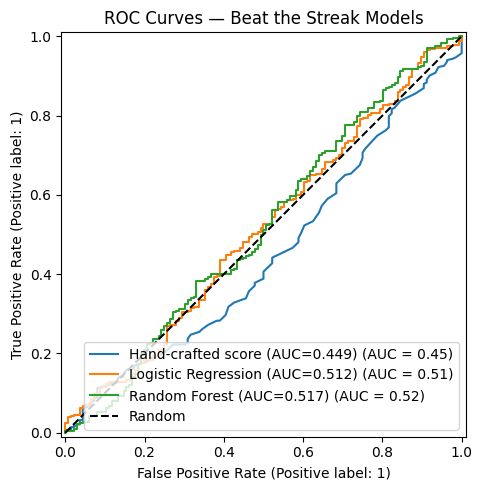


Summary
----------------------------------------
Hand-crafted score AUC : 0.4492
Logistic Regression AUC: 0.5122  (delta: +0.0630)
Random Forest AUC      : 0.5169  (delta: +0.0677)


In [10]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(y_test, score_proba.ravel(), name=f'Hand-crafted score (AUC={baseline_auc:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, lr_proba, name=f'Logistic Regression (AUC={lr_auc:.3f})', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name=f'Random Forest (AUC={rf_auc:.3f})', ax=ax)

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curves — Beat the Streak Models')
ax.legend()
plt.tight_layout()
plt.show()

print('\nSummary')
print('-' * 40)
print(f'Hand-crafted score AUC : {baseline_auc:.4f}')
print(f'Logistic Regression AUC: {lr_auc:.4f}  (delta: {lr_auc - baseline_auc:+.4f})')
print(f'Random Forest AUC      : {rf_auc:.4f}  (delta: {rf_auc - baseline_auc:+.4f})')

## Feature importance (Random Forest)

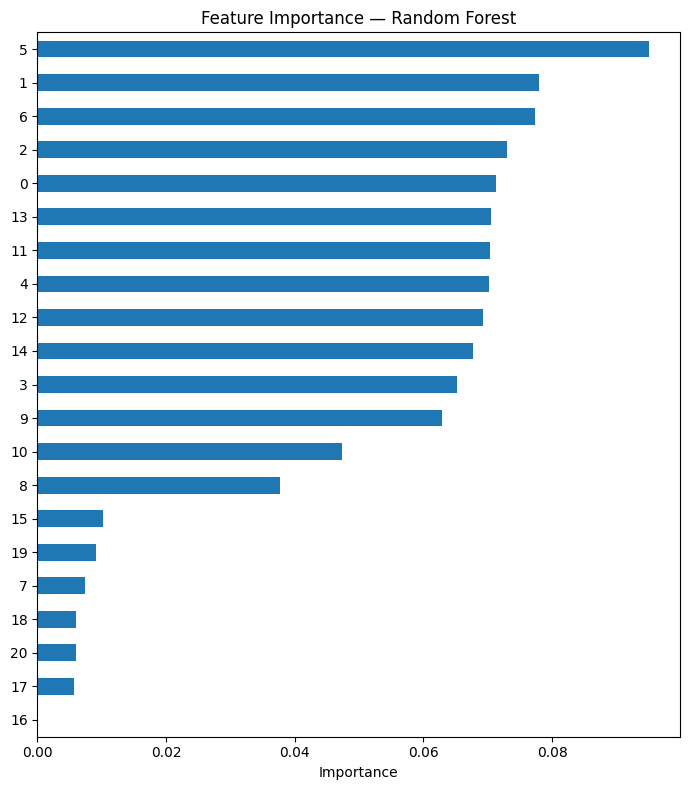

Top 10 features:
5     0.0951
1     0.0780
6     0.0773
2     0.0730
0     0.0712
13    0.0706
11    0.0704
4     0.0703
12    0.0692
14    0.0676


In [11]:
importances = rf_pipeline.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 8))
feat_imp.plot(kind='barh', ax=ax)
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.tail(10).sort_values(ascending=False).round(4).to_string())

## Logistic Regression coefficients (which direction do features push the model?)

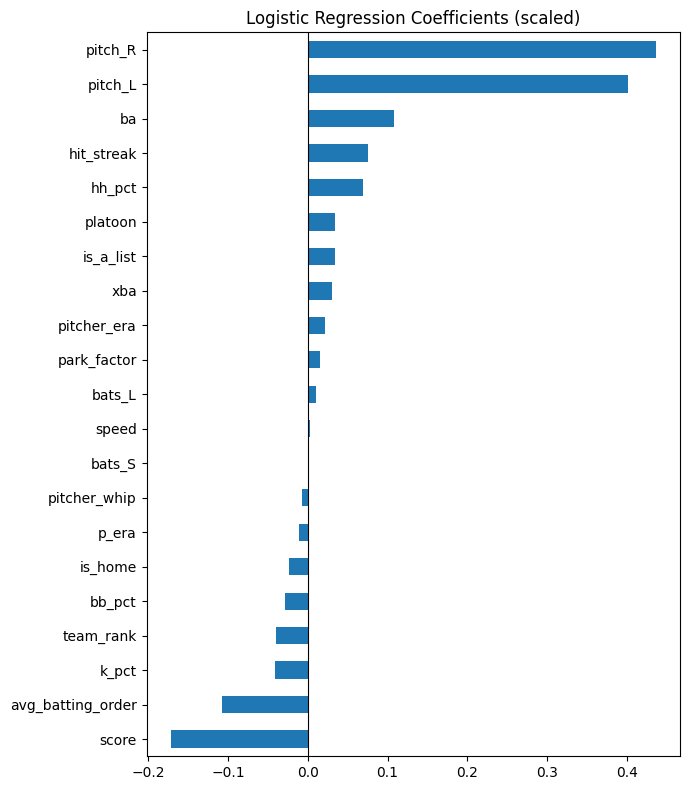

In [12]:
coef = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=FEATURE_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(7, 8))
coef.plot(kind='barh', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (scaled)')
plt.tight_layout()
plt.show()

## Save the best model

Once you have enough data and are happy with a model, save it here.

In [13]:
import joblib
import os

# Pick the better model
best_model = rf_pipeline if rf_auc >= lr_auc else lr_pipeline
best_name = 'random_forest' if rf_auc >= lr_auc else 'logistic_regression'

models_dir = os.path.join(PROJECT_ROOT, 'data', 'models')
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, f'hit_predictor_{best_name}.joblib')
joblib.dump({
    'model': best_model,
    'feature_cols': FEATURE_COLS,
    'auc': max(rf_auc, lr_auc),
    'baseline_auc': baseline_auc,
}, model_path)

print(f'Model saved to {model_path}')
print(f'AUC: {max(rf_auc, lr_auc):.4f} vs baseline {baseline_auc:.4f}')

Model saved to /Users/kxkmi5556/PycharmProjects/beat_the_streak_2026/data/models/hit_predictor_random_forest.joblib
AUC: 0.5169 vs baseline 0.4492
